## ASSIGNMET 1  WEEK 2

# Task 1: Linear Regression on Housing Dataset

In this task, we will build a Linear Regression model using a housing dataset to predict house prices.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Load the Housing Dataset

We load the housing dataset using Pandas and display the first five rows to understand its structure.

In [2]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Check the Dataset

We inspect the dataset information to understand the columns, data types, and number of records.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


## Convert Categorical Variables into Numerical Values

The housing dataset contains categorical variables. We use one-hot encoding to convert these categorical values into numerical values that can be used by the Linear Regression model.

In [4]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Separate Features and Target Variable

The target variable is `price`, because our objective is to predict the price of a house.

All other columns are used as input features.

In [5]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   area  bedrooms  bathrooms  stories  parking  mainroad_yes  guestroom_yes  \
0  7420         4          2        3        2          True          False   
1  8960         4          4        4        3          True          False   
2  9960         3          2        2        2          True          False   
3  7500         4          2        2        3          True          False   
4  7420         4          1        2        2          True           True   

   basement_yes  hotwaterheating_yes  airconditioning_yes  prefarea_yes  \
0         False                False                 True          True   
1         False                False                 True         False   
2          True                False                False          True   
3          True                False                 True          True   
4          True                False                 True         False   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished

## Split the Dataset into Training and Testing Data

We divide the dataset into training and testing sets. The training data is used to train the model, while the testing data is used to make predictions on unseen data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


## Train the Linear Regression Model

We create a Linear Regression model and train it using the training data.

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Predict House Prices

The trained Linear Regression model is used to predict house prices for the testing dataset.

In [8]:
y_pred = model.predict(X_test)

print("First five predicted house prices:")
print(y_pred[:5])

First five predicted house prices:
[5164653.90033968 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


## ASSIGNMENT 2

# Task 2: Logistic Regression on Titanic Dataset

In this task, we will train a Logistic Regression model to predict whether a passenger survived the Titanic disaster.

In [9]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## Load the Titanic Dataset

We load the Titanic dataset using Pandas and display the first five rows.

In [11]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Check the Dataset

We inspect the dataset to understand its columns, data types, and missing values.

In [12]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Select Features and Target Variable

We select passenger class, sex, age, number of siblings/spouses, number of parents/children, and fare as input features.

The target variable is `Survived`, which indicates whether the passenger survived.

In [13]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].copy()
y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


## Handle Missing Values and Convert Categorical Data

The `Age` column may contain missing values, so we replace them with the median age.

The `Sex` column contains categorical values, so we convert male and female into numerical values.

In [14]:
X["Age"] = X["Age"].fillna(X["Age"].median())

X["Sex"] = X["Sex"].map({
    "male": 0,
    "female": 1
})

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


## Split the Dataset into Training and Testing Data

We divide the Titanic dataset into training and testing sets. The model will learn from the training data and make predictions on the testing data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 6)
Testing data: (179, 6)


## Train the Logistic Regression Model

We create a Logistic Regression model and train it using the training data.

In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Predict Passenger Survival

The trained Logistic Regression model is used to predict whether passengers in the testing dataset survived.

In [17]:
y_pred = model.predict(X_test)

print("First ten survival predictions:")
print(y_pred[:10])

First ten survival predictions:
[0 0 0 1 1 1 1 0 1 1]


# Mini Project 2: House Price Prediction Model

In this project, we will build a Linear Regression model to predict house prices using the House Prices dataset.

The main tasks are:
1. Train a Linear Regression model
2. Predict house prices
3. Evaluate the model using R² score
4. Plot predicted vs actual house prices

## Import Required Libraries

We import the required Python libraries for data handling, model training, evaluation, and visualization.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Load the House Prices Dataset

We load the housing dataset using Pandas and display the first five rows to understand its structure.

In [19]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Prepare the Dataset

The dataset contains both numerical and categorical features. We use one-hot encoding to convert categorical variables into numerical values so that they can be used by the Linear Regression model.

In [20]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Separate Features and Target Variable

The `price` column is the target variable because our objective is to predict house prices.

All other columns are used as input features.

In [21]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 13)
Target shape: (545,)


## Split the Dataset into Training and Testing Data

We split the dataset into training and testing sets.

The training data is used to train the model, while the testing data is used to evaluate its predictions on unseen data.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


## Train the Linear Regression Model

We create a Linear Regression model and train it using the training dataset.

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Predict House Prices

The trained Linear Regression model is used to predict house prices for the testing dataset.

In [24]:
y_pred = model.predict(X_test)

print("First five predicted house prices:")
print(y_pred[:5])

First five predicted house prices:
[5164653.90033968 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


## Evaluate the Model Using R² Score

The R² score measures how well the Linear Regression model explains the variation in the actual house prices.

A value closer to 1 indicates better model performance.

In [25]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6529242642153186


## Plot Predicted vs Actual House Prices

We create a scatter plot to compare the actual house prices with the prices predicted by the Linear Regression model.

If the predictions are close to the actual values, the points will be closer to a diagonal pattern.

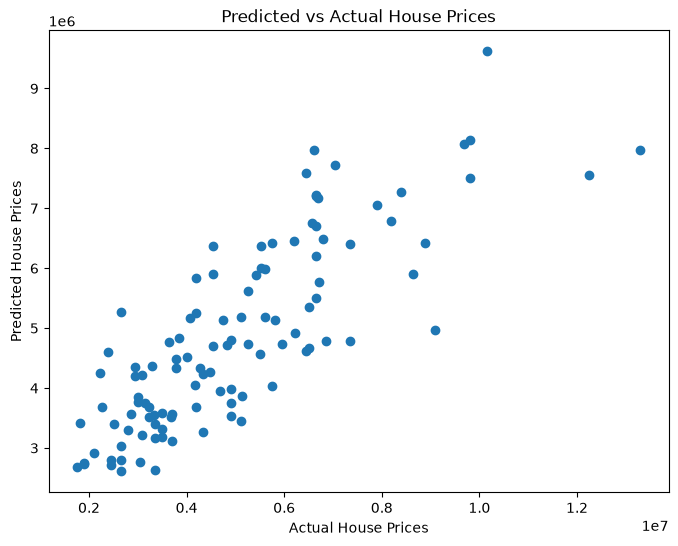

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Predicted vs Actual House Prices")

plt.show()

## Plot Predicted vs Actual Values with Regression Trend Line

This plot shows the predicted house prices against the actual house prices along with a regression trend line.

In [29]:
line_model = LinearRegression()

line_model.fit(
    y_test.values.reshape(-1, 1),
    y_pred
)

line_pred = line_model.predict(
    y_test.values.reshape(-1, 1)
)

print("Linear regression trend line created successfully.")

Linear regression trend line created successfully.


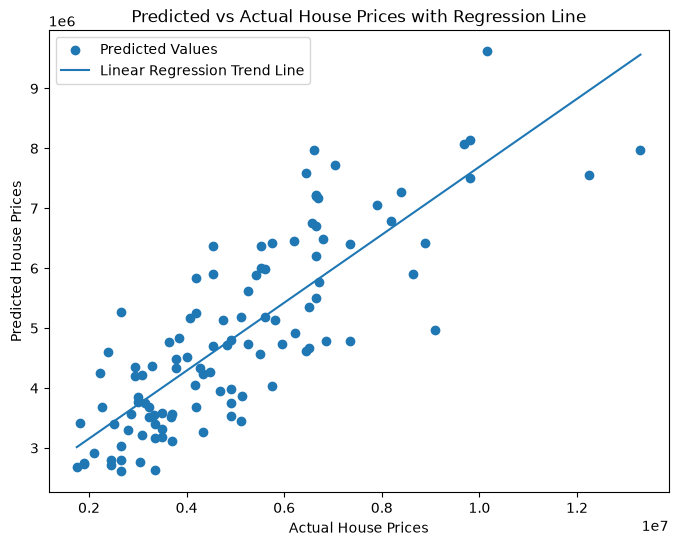

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, label="Predicted Values")

sorted_indices = y_test.argsort()

plt.plot(
    y_test.iloc[sorted_indices],
    line_pred[sorted_indices],
    label="Linear Regression Trend Line"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Predicted vs Actual House Prices with Regression Line")
plt.legend()

plt.show()

## Conclusion

In this project, a Linear Regression model was developed to predict house prices using the housing dataset. The categorical data was converted into numerical form, and the dataset was divided into training and testing sets.

The model successfully predicted house prices, and its performance was evaluated using the R² score. The predicted and actual house prices were also visualized using scatter plots, including a regression trend line.

The model achieved an R² score of approximately **0.653**, which means that the model explains about **65.3% of the variation in house prices**. Overall, the project demonstrates how Linear Regression can be used for house price prediction.
